In [2]:
import os
print(os.getcwd())

c:\Users\Dhruvi\Intelligent-Traffic-Prediction-Congestion-Analysis-System\src\models


In [3]:
import pandas as pd
import numpy as np
import joblib

In [4]:
df = pd.read_csv("../../data/processed/cleaned_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (48187, 12)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day,month
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10


In [5]:
df['date_time'] = pd.to_datetime(df['date_time'])

df = df.sort_values('date_time').reset_index(drop=True)

In [6]:
df = df.fillna(method='ffill')
df['holiday'] = df['holiday'].fillna('None')

C:\Users\Dhruvi\AppData\Local\Temp\ipykernel_13904\1750837822.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [7]:
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month

In [8]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['day_sin'] = np.sin(2 * np.pi * df['day'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [9]:
df = pd.get_dummies(df, columns=[
    'weather_main'
], drop_first=True)

In [10]:
df['traffic_lag_1'] = df['traffic_volume'].shift(1)
df['traffic_lag_24'] = df['traffic_volume'].shift(24)

In [11]:
df = pd.get_dummies(df, columns=['holiday'], drop_first=True)

In [12]:
df = df.drop(columns=['date_time','weather_description'])

In [13]:
df = df.dropna()

In [14]:
split = int(0.8 * len(df))

train_df = df[:split]
test_df = df[split:]

In [15]:
X_train = train_df.drop(columns=['traffic_volume'])
y_train = train_df['traffic_volume']

X_test = test_df.drop(columns=['traffic_volume'])
y_test = test_df['traffic_volume']

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
df.head()
df.shape

(48163, 37)

In [18]:
def create_sequences(X, y, time_steps=24):
    X = np.array(X)
    y = np.array(y)

    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])

    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, 24)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, 24)

In [19]:
print(X_train_seq.shape)
print(y_train_seq.shape)

(38506, 24, 36)
(38506,)


In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\Dhruvi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,817 (151.63 KB)

 Trainable params: 38,817 (151.63 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3
    )
]

history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 13222817.0000 - mae: 3047.1931 - val_loss: 12549715.0000 - val_mae: 2949.0229 - learning_rate: 0.0010
Epoch 2/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 9159591.0000 - mae: 2477.1768 - val_loss: 7688110.5000 - val_mae: 2344.5713 - learning_rate: 0.0010
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5513155.0000 - mae: 2003.1464 - val_loss: 4813740.0000 - val_mae: 1929.4204 - learning_rate: 0.0010
Epoch 4/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 4187358.5000 - mae: 1791.7720 - val_loss: 4138467.7500 - val_mae: 1791.6934 - learning_rate: 0.0010
Epoch 5/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 4026422.5000 - mae: 1761.0192 - val_loss: 4056746.7500 - val_mae: 1772.4456 - learning_rate: 0.0010
Epoch 6/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 4023861.7500 - mae: 1757.6199 - val_loss: 4058291.5000 - val_mae: 1772.8486 - learning_rate: 0.0010
Epoch 7/30
963/963 ━━━━━━━━━━

In [58]:
loss, mae = model.evaluate(X_test_seq, y_test_seq)
print("Test MAE:", mae)

301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 190483.0156 - mae: 283.4526
Test MAE: 283.45263671875


In [20]:
import tensorflow as tf

model = tf.keras.models.load_model("traffic_model.h5", compile=False)

In [21]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [22]:
import joblib

scaler = joblib.load("X_scaler.pkl")


In [23]:
y_pred = model.predict(X_test_seq)

301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


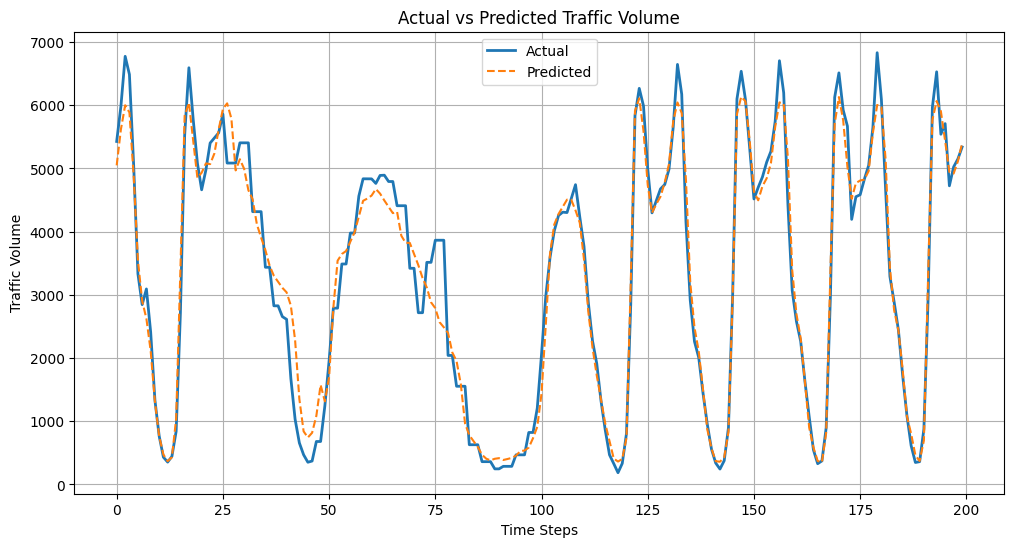

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_seq[:200], label='Actual', linewidth=2)
plt.plot(y_pred[:200], label='Predicted', linestyle='--')

plt.title("Actual vs Predicted Traffic Volume")
plt.xlabel("Time Steps")
plt.ylabel("Traffic Volume")
plt.legend()
plt.grid()

plt.show()

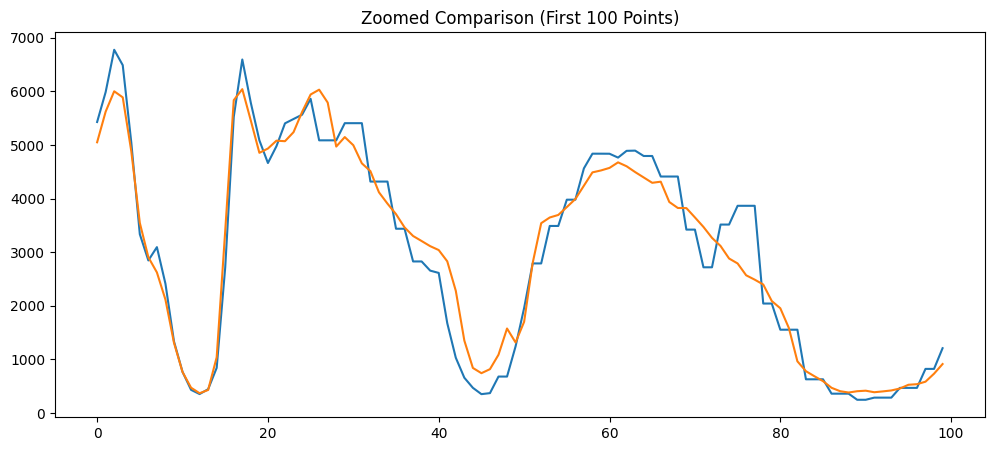

In [25]:
plt.figure(figsize=(12,5))
plt.plot(y_test_seq[:100])
plt.plot(y_pred[:100])
plt.title("Zoomed Comparison (First 100 Points)")
plt.show()

In [61]:
model.save("traffic_model.h5")
joblib.dump(scaler, "X_scaler.pkl")


['X_scaler.pkl']